In [1]:
import nbimporter
from torch.utils.data.dataset import Dataset
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchvision import transforms
from torch import nn
from torch.optim import SGD
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, auc
from os.path import join
import torch
import numpy as np
from PIL import Image
from os import path

import python_file.dataclass as StreetSign
import python_file.function as Function
import python_file.network as Network

import matplotlib.pyplot as plt

from python_file.dirPath import csvDir, imageDir, Test, historiesDir

np.random.seed(1328)
torch.random.manual_seed(1328)

In [2]:
#resize normale
tran = transforms.Compose([StreetSign.Rescale(32),StreetSign.RandomCrop(32),StreetSign.ToTensor()])

In [3]:
datatrain = StreetSign.StreetSignDataset(csvDir / 'classes.csv',imageDir,tran)
datatest = StreetSign.StreetSignTest( Test / 'prova.txt',Test,tran)

In [4]:
datatrain_loader = DataLoader(datatrain, batch_size=1024, shuffle=True)
datatest_loader = DataLoader(datatest, batch_size=1024, shuffle=True)

In [5]:
#number of epoch
epoche = 200
learning_rate=0.0001

<h1>Momento 0.3</h1>

In [6]:
momento = 0.3
exp_name='minialexnetV2_lr0001_m03'

In [7]:
minialexnetV2_datatrain = Network.MiniAlexNetV2()

minialexnetV2_datatrain = Function.train_classifier(minialexnetV2_datatrain, datatrain_loader, datatest_loader, \
                                                    exp_name, learning_rate, epoche, momento, save_model=True)

minialexnetV2_data_test_probabilities, data_labels_test = Function.test_classifier(minialexnetV2_datatrain,
                                                                                   datatest_loader)

data_labels_test

array([0, 1, 0, 1, 1, 1, 1, 1, 1, 2, 0, 1, 0, 1, 2, 2, 1, 2, 1, 1, 0, 1,
       2, 2, 1, 2, 0, 1, 0, 0, 1, 1, 0, 1, 2, 1, 1, 2, 2, 0, 0, 0, 1, 2,
       2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       2, 1, 1, 1, 0, 1, 2, 1, 1, 1, 0, 2, 2, 0, 1, 0, 2, 1, 2, 2, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 0, 1, 0, 1, 1, 0, 2, 1, 1, 1, 0, 0,
       2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 0, 1, 2, 2, 0, 2, 2, 2, 2, 2, 2, 0, 0, 1, 1, 2,
       0, 0, 1, 1, 2, 1, 0, 1, 1, 0, 1, 1, 2, 2, 2, 2, 1, 0, 2, 0, 1, 2,
       1, 1, 2, 1, 1, 1, 1, 0, 1, 2, 1, 2, 1, 1, 0, 1, 2, 0, 2, 2, 0, 2,
       2, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 0, 1, 2, 1, 0, 0, 1, 1, 0, 1, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 2,
       2, 2, 1, 2, 2, 1, 0, 1, 1, 1, 1, 0, 2, 0, 1, 1, 2, 1, 1, 0, 2, 1,
       1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 0, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2,
       1, 1, 1, 2, 1, 1, 2, 2, 0, 2, 1, 0, 0, 1, 1,

In [8]:
file_csv = historiesDir / f'{exp_name}-{epoche}.csv'

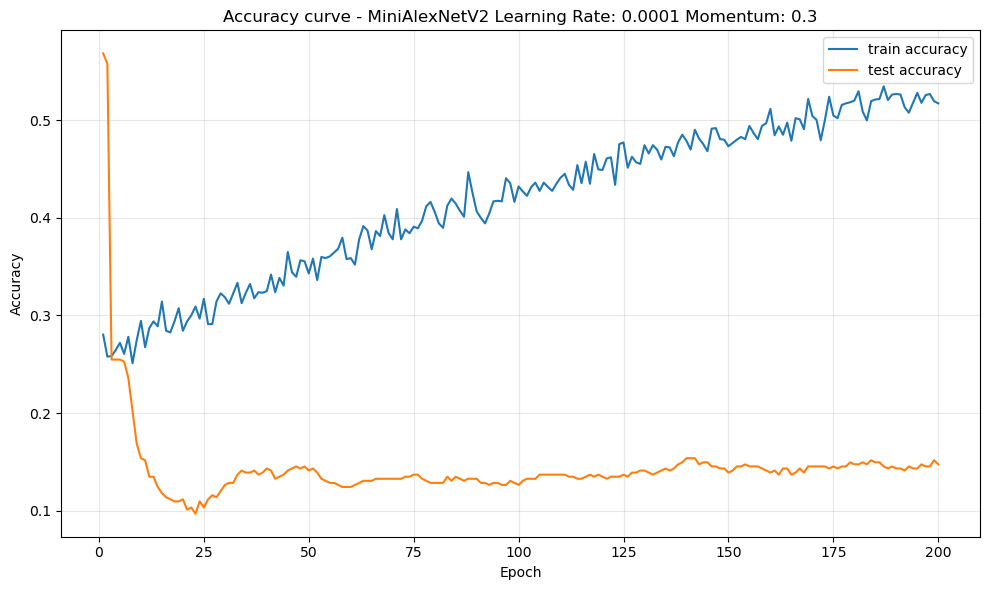

In [9]:
Function.plot_accuracy_from_csv(file_csv , "Accuracy curve - MiniAlexNetV2 Learning Rate: 0.0001 Momentum: 0.3")

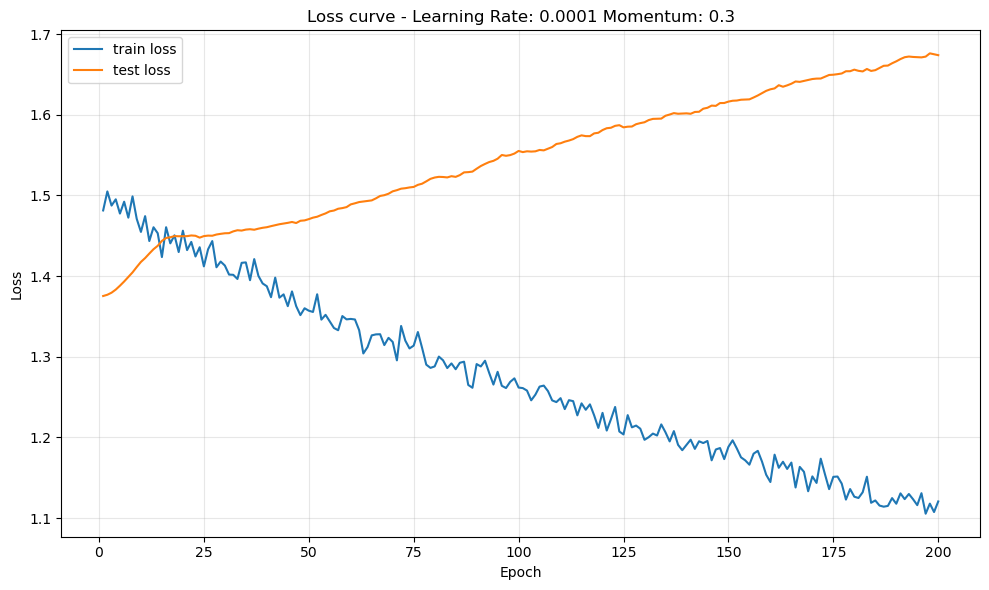

In [10]:
Function.plot_loss_from_csv(file_csv, "Loss curve - Learning Rate: 0.0001 Momentum: 0.3")

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.703
  Classe 1: 0.668
  Classe 2: 0.742

AUC macro (media): 0.705


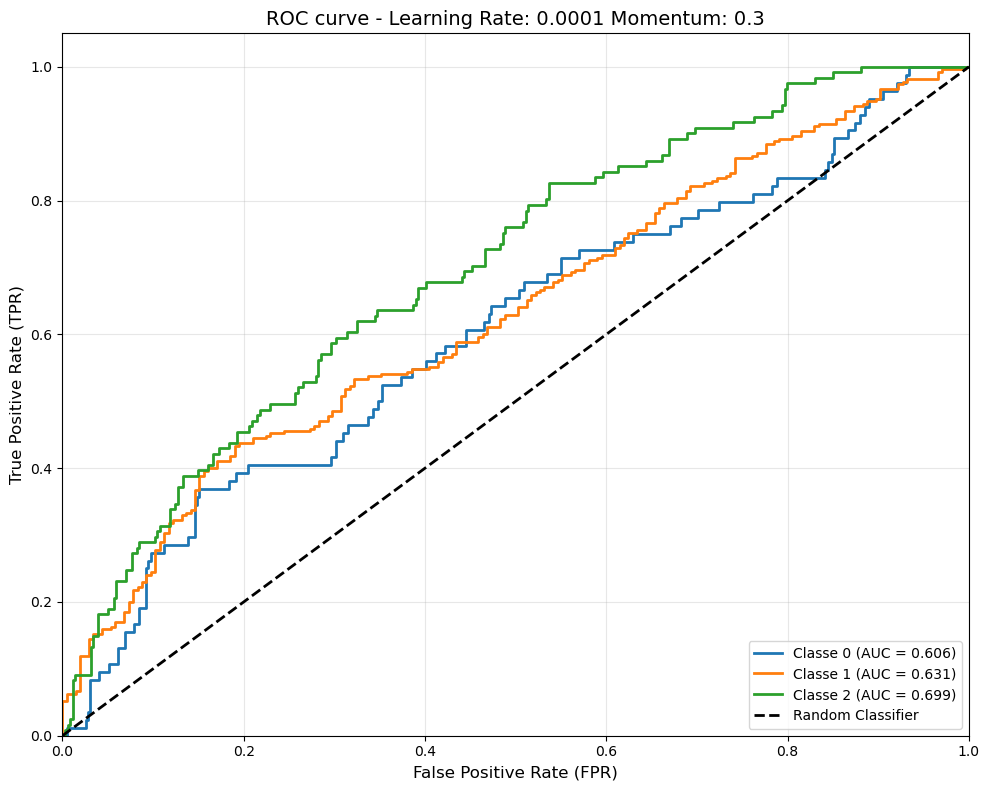

In [11]:
Function.plot_roc_curve(data_labels_test, minialexnetV2_data_test_probabilities, "ROC curve - Learning Rate: 0.0001 Momentum: 0.3")

<h1>Momento 0.9</h1>

In [12]:
momento = 0.9
exp_name='minialexnetV2_lr0001_m09'

In [13]:
minialexnetV2_datatrain = Network.MiniAlexNetV2()

minialexnetV2_datatrain = Function.train_classifier(minialexnetV2_datatrain, datatrain_loader, datatest_loader, \
                                                    exp_name, learning_rate, epoche, momento, save_model=True)

minialexnetV2_data_test_probabilities, data_labels_test = Function.test_classifier(minialexnetV2_datatrain,
                                                                                   datatest_loader)

data_labels_test

array([1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 1, 1, 1, 2, 1, 1, 0, 2, 0, 1, 1, 2,
       1, 0, 2, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 2, 1, 0, 1, 2, 1, 0, 1, 1, 0, 2, 1, 1, 1, 1, 1, 2,
       0, 1, 2, 2, 1, 1, 1, 1, 1, 1, 2, 0, 2, 1, 2, 0, 2, 1, 0, 2, 2, 1,
       2, 0, 0, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 0, 2, 0, 1, 1, 0, 1, 1,
       2, 2, 1, 2, 1, 0, 1, 1, 2, 1, 2, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 1, 1, 0, 0, 0, 1,
       2, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1, 2, 2, 1, 2, 1, 1, 2, 2, 1, 2,
       1, 2, 2, 0, 1, 0, 1, 1, 1, 1, 1, 2, 0, 0, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 1, 0, 2, 2, 0, 2, 1, 1, 1, 0, 1, 2, 1, 1,
       1, 2, 0, 2, 1, 1, 0, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 0, 0,
       2, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 2, 0, 0, 1, 2, 1, 1, 1, 1, 1,
       2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 0, 2, 1, 1, 0, 1, 1, 1, 0, 2, 1, 1,
       1, 1, 2, 1, 1, 1, 2, 0, 1, 2, 1, 1, 1, 1, 1,

In [14]:
file_csv = historiesDir / f'{exp_name}-{epoche}.csv'

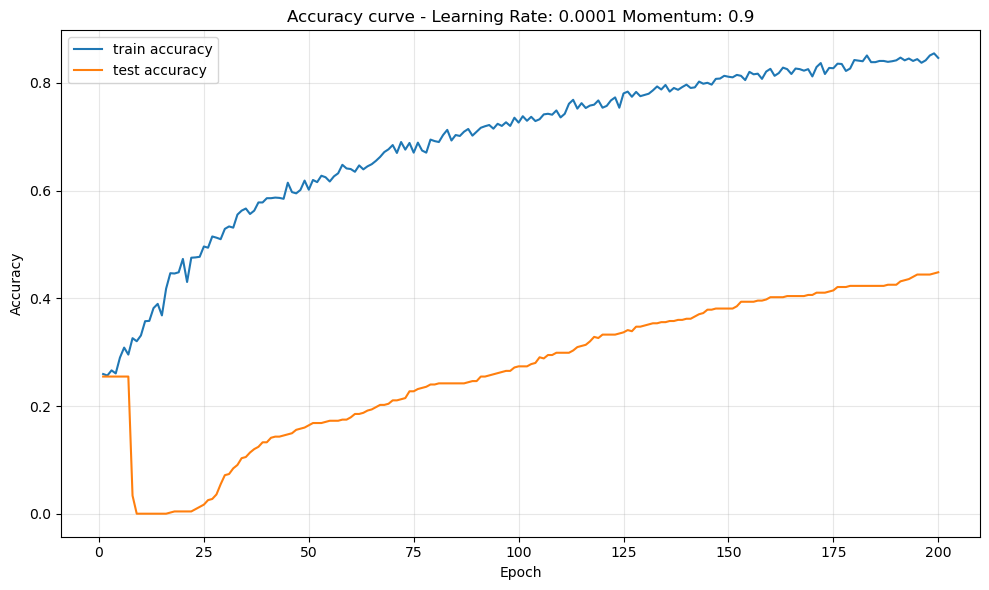

In [15]:
Function.plot_accuracy_from_csv(file_csv , "Accuracy curve - Learning Rate: 0.0001 Momentum: 0.9")

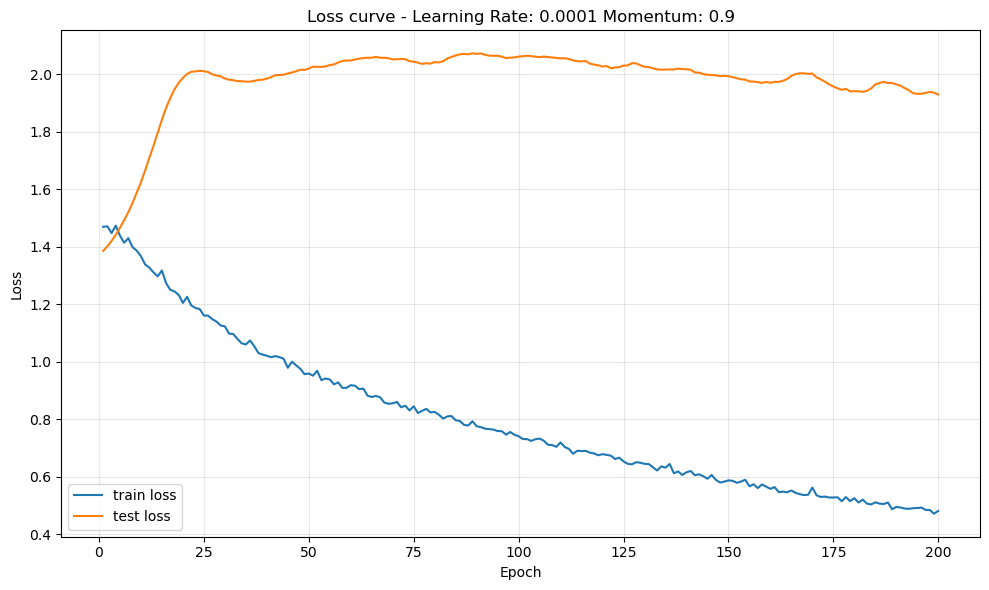

In [16]:
Function.plot_loss_from_csv(file_csv, "Loss curve - Learning Rate: 0.0001 Momentum: 0.9")

Classi nel test set: [0 1 2]
Somma probabilità (dopo normalizzazione): 1.0000

AUC per classe:
  Classe 0: 0.798
  Classe 1: 0.810
  Classe 2: 0.885

AUC macro (media): 0.831


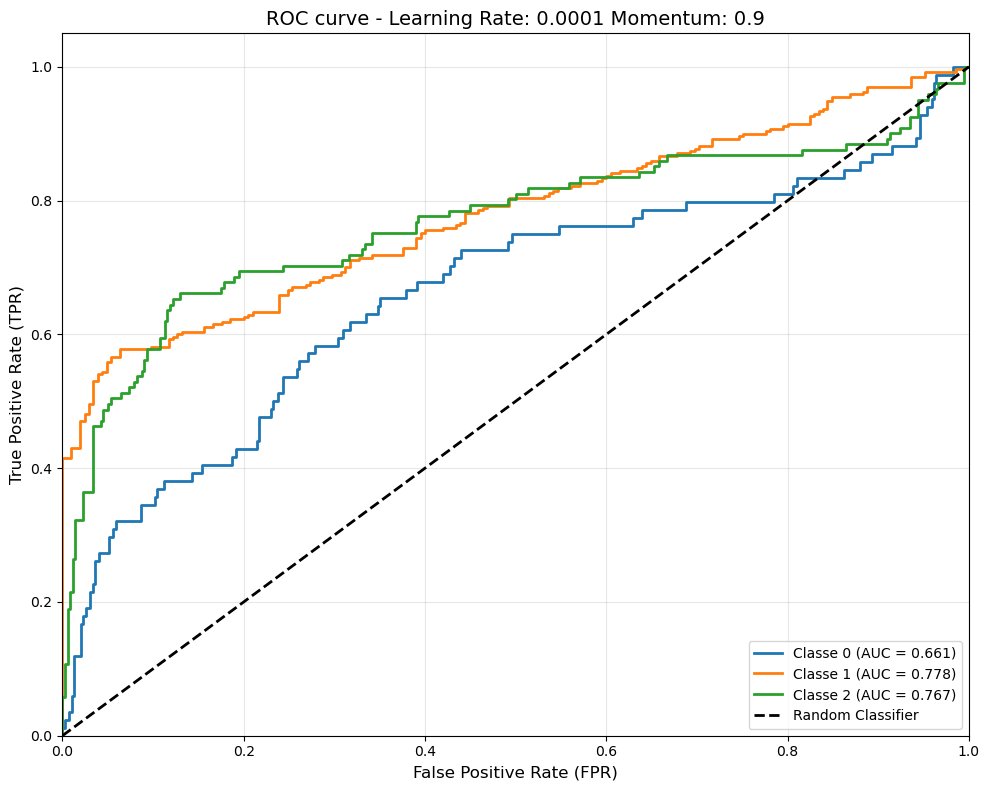

In [17]:
Function.plot_roc_curve(data_labels_test, minialexnetV2_data_test_probabilities, "ROC curve - Learning Rate: 0.0001 Momentum: 0.9")